# Classificação de Tumores utilizando SVM

## Breast Cancer Wisconsin

Nesta atividade vou utilizar o dataset Breast Cancer Wisconsin para criar
um modelo capaz de classificar tumores como benignos ou malignos.

O dataset possui informações retiradas de exames de massas mamárias e
contém várias características das células analisadas.

Durante a atividade vou primeiro conhecer e organizar os dados. Depois,
vou separar os dados para treinamento e teste, realizar a padronização
e utilizar o algoritmo SVM com os kernels Linear e RBF.

Por fim, vou comparar os resultados dos modelos e testar diferentes
valores dos parâmetros C e gamma para verificar quais apresentam
melhores resultados.

In [103]:
# Biblioteca utilizada para trabalhar com os dados
import pandas as pd

# Biblioteca utilizada para criar os gráficos
import matplotlib.pyplot as plt

# Ferramentas utilizadas para separar os dados e testar os parâmetros
import sklearn.model_selection

# Ferramenta utilizada para padronizar os dados
import sklearn.preprocessing

# Biblioteca que possui o modelo SVM
import sklearn.svm

# Métricas utilizadas para avaliar os modelos
import sklearn.metrics

## Importação das bibliotecas

Primeiro importei as bibliotecas que vou utilizar durante a atividade.

O pandas será utilizado para ler e organizar os dados. O matplotlib será
utilizado para criar os gráficos e o sklearn será utilizado nas principais
etapas de Machine Learning, como separação dos dados, padronização,
treinamento do SVM e avaliação dos resultados.

In [104]:
# Biblioteca para acessar as pastas do Kaggle
import os

# Procura e mostra os arquivos disponíveis no notebook
for pasta, _, arquivos in os.walk('/kaggle/input'):
    for arquivo in arquivos:
        print(os.path.join(pasta, arquivo))

/kaggle/input/datasets/uciml/breast-cancer-wisconsin-data/data.csv


In [105]:
# Lendo o arquivo CSV do dataset
df = pd.read_csv('/kaggle/input/datasets/uciml/breast-cancer-wisconsin-data/data.csv')

# Mostrando as 5 primeiras linhas
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


## Carregamento do dataset

Nesta etapa carreguei o arquivo do dataset utilizando o pandas.

Depois utilizei o comando head() para visualizar as cinco primeiras
linhas. Fiz isso para conhecer melhor como os dados estão organizados
e quais informações estão presentes.

In [106]:
# Mostra a quantidade de linhas e colunas
print("Quantidade de linhas e colunas:", df.shape)

# Mostra informações sobre as colunas
df.info()

Quantidade de linhas e colunas: (569, 33)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null 

In [107]:
# Mostra o nome de todas as colunas
df.columns

Index(['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst', 'Unnamed: 32'],
      dtype='object')

In [108]:
# Mostra algumas informações estatísticas sobre os dados
df.describe()

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,0.0
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,NaN
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,NaN
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,NaN
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,NaN
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,NaN
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,NaN
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,NaN


## Conhecendo o dataset

Antes de começar o treinamento, procurei conhecer melhor o dataset.

Primeiro verifiquei a quantidade de linhas e colunas. Depois analisei os
tipos de dados presentes em cada coluna e também algumas informações
estatísticas, como média, valor mínimo e valor máximo.

Essa análise inicial é importante para entender os dados antes de realizar
qualquer alteração neles.

In [109]:
# Verifica quantos valores vazios existem em cada coluna
df.isnull().sum()

id                           0
diagnosis                    0
radius_mean                  0
texture_mean                 0
perimeter_mean               0
area_mean                    0
smoothness_mean              0
compactness_mean             0
concavity_mean               0
concave points_mean          0
symmetry_mean                0
fractal_dimension_mean       0
radius_se                    0
texture_se                   0
perimeter_se                 0
area_se                      0
smoothness_se                0
compactness_se               0
concavity_se                 0
concave points_se            0
symmetry_se                  0
fractal_dimension_se         0
radius_worst                 0
texture_worst                0
perimeter_worst              0
area_worst                   0
smoothness_worst             0
compactness_worst            0
concavity_worst              0
concave points_worst         0
symmetry_worst               0
fractal_dimension_worst      0
Unnamed:

## Verificação de dados vazios

Nesta parte verifiquei se existiam valores vazios no dataset.

Essa verificação é importante porque informações ausentes podem causar
problemas durante o treinamento do modelo.

Ao analisar o resultado, foi possível perceber que existe uma coluna
chamada "Unnamed: 32" que não possui informações úteis.

In [110]:
# Remove as colunas que não serão necessárias
df = df.drop(columns=['id', 'Unnamed: 32'])

# Mostra novamente as primeiras linhas
df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [111]:
# Verifica o tamanho do dataset depois da remoção
df.shape

(569, 31)

## Limpeza dos dados

Depois de analisar o dataset, removi duas colunas que não seriam
necessárias para o treinamento.

A coluna "id" foi removida porque serve apenas para identificar cada
registro e não ajuda o modelo a descobrir se o tumor é benigno ou maligno.

Também removi a coluna "Unnamed: 32", pois ela não possui informações
importantes para a análise.

Dessa forma, mantive somente os dados que realmente podem ajudar
na classificação.

In [112]:
# Conta quantos casos existem de cada diagnóstico
df['diagnosis'].value_counts()

diagnosis
B    357
M    212
Name: count, dtype: int64

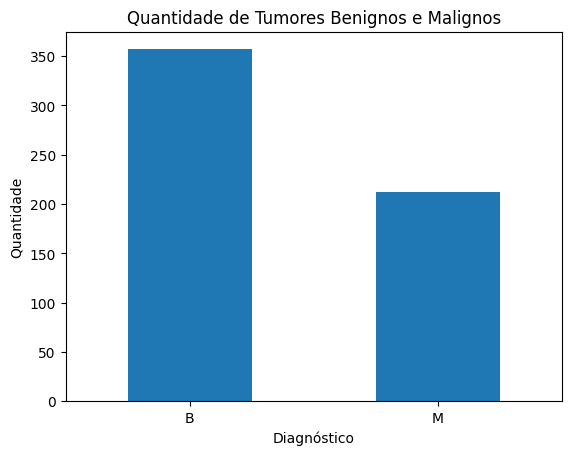

In [113]:
# Cria um gráfico com a quantidade de tumores benignos e malignos
df['diagnosis'].value_counts().plot(kind='bar')

# Título do gráfico
plt.title('Quantidade de Tumores Benignos e Malignos')

# Nome dos eixos
plt.xlabel('Diagnóstico')
plt.ylabel('Quantidade')

# Deixa os nomes B e M na horizontal
plt.xticks(rotation=0)

# Mostra o gráfico
plt.show()

## Análise dos diagnósticos

Também analisei a quantidade de tumores benignos e malignos presentes
no dataset.

A letra B representa os tumores benignos e a letra M representa os
tumores malignos.

Além de visualizar a quantidade de cada classe, criei um gráfico para
facilitar a comparação entre elas. Assim consigo entender melhor como
os diagnósticos estão distribuídos antes de treinar o modelo.

In [114]:
# Converte os diagnósticos para valores numéricos
# B (Benigno) = 0
# M (Maligno) = 1

df['diagnosis'] = df['diagnosis'].map({
    'B': 0,
    'M': 1
})

# Mostra as primeiras linhas após a alteração
df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


## Transformação da variável diagnosis

A coluna "diagnosis" estava representada pelas letras B e M.

Para facilitar a utilização dessas informações pelo modelo, transformei
os valores em números.

Utilizei 0 para representar os tumores benignos e 1 para representar os
tumores malignos.

Com isso, a variável que o modelo deverá prever passou a estar em um
formato numérico.

In [115]:
# X recebe as características utilizadas para fazer a classificação
X = df.drop(columns=['diagnosis'])

# y recebe o resultado que queremos prever
y = df['diagnosis']

# Mostra a quantidade de dados
print("Quantidade de registros:", X.shape[0])
print("Quantidade de características:", X.shape[1])

Quantidade de registros: 569
Quantidade de características: 30


## Separação das variáveis

Nesta etapa separei os dados entre X e y.

Em X ficaram todas as características que serão utilizadas pelo SVM
para aprender a diferença entre os tumores.

Em y ficou apenas o diagnóstico, que é justamente a informação que
queremos que o modelo consiga prever.

Portanto, o modelo vai analisar as características presentes em X para
tentar descobrir o valor correto de y.

In [116]:
# Separa 80% dos dados para treinamento e 20% para teste
X_train, X_test, y_train, y_test = sklearn.model_selection.train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Mostra a quantidade de registros de cada conjunto
print("Dados de treinamento:", X_train.shape)
print("Dados de teste:", X_test.shape)

Dados de treinamento: (455, 30)
Dados de teste: (114, 30)


## Separação entre treino e teste

Separei o dataset em duas partes.

Utilizei 80% dos dados para treinamento e 20% para teste.

Os dados de treinamento serão utilizados para o SVM aprender os padrões
existentes. Já os dados de teste serão utilizados para verificar se o
modelo consegue classificar corretamente informações que ele ainda não
viu durante o treinamento.

Também utilizei o stratify para manter uma proporção parecida de tumores
benignos e malignos nos dois conjuntos.

In [117]:
# Cria o padronizador
scaler = sklearn.preprocessing.StandardScaler()

# Aprende a escala utilizando somente os dados de treinamento
# e transforma os dados
X_train_scaled = scaler.fit_transform(X_train)

# Aplica a mesma transformação nos dados de teste
X_test_scaled = scaler.transform(X_test)

## Padronização dos dados

Antes de treinar o SVM, realizei a padronização das características
utilizando o StandardScaler.

Essa etapa é importante porque as características do dataset possuem
valores em escalas diferentes. Algumas podem apresentar valores muito
maiores do que outras.

Como o SVM utiliza distâncias durante seu funcionamento, essas diferenças
de escala podem acabar influenciando o resultado.

O StandardScaler ajuda a colocar as características em uma escala mais
parecida.

Primeiro fiz o ajuste utilizando somente os dados de treinamento e depois
apliquei a mesma transformação nos dados de teste. Isso evita utilizar
informações do conjunto de teste durante o treinamento.

In [118]:
# Cria o modelo SVM utilizando o kernel Linear
svm_linear = sklearn.svm.SVC(
    kernel='linear',
    C=1
)

# Treina o modelo
svm_linear.fit(X_train_scaled, y_train)

# Faz as previsões utilizando os dados de teste
y_pred_linear = svm_linear.predict(X_test_scaled)

## SVM com Kernel Linear

O primeiro modelo que treinei foi o SVM utilizando o kernel Linear.

Esse kernel tenta encontrar uma separação linear entre as duas classes,
neste caso, tumores benignos e malignos.

Inicialmente utilizei C igual a 1. Mais adiante vou testar outros valores
desse parâmetro para verificar se o resultado pode melhorar.

In [119]:
# Calcula as principais métricas do modelo
accuracy_linear = sklearn.metrics.accuracy_score(
    y_test, y_pred_linear
)

precision_linear = sklearn.metrics.precision_score(
    y_test, y_pred_linear
)

recall_linear = sklearn.metrics.recall_score(
    y_test, y_pred_linear
)

f1_linear = sklearn.metrics.f1_score(
    y_test, y_pred_linear
)

# Mostra os resultados
print("Accuracy:", accuracy_linear)
print("Precision:", precision_linear)
print("Recall:", recall_linear)
print("F1-score:", f1_linear)

Accuracy: 0.9649122807017544
Precision: 1.0
Recall: 0.9047619047619048
F1-score: 0.95


## Avaliação do SVM Linear

Depois do treinamento, utilizei os dados de teste para avaliar o modelo.

Não analisei somente a quantidade total de acertos. Também utilizei
Accuracy, Precision, Recall e F1-score.

A Accuracy mostra de forma geral quantas classificações foram corretas.
A Precision ajuda a verificar a precisão das classificações positivas.
O Recall mostra quantos casos positivos reais foram encontrados pelo
modelo.

Já o F1-score procura equilibrar Precision e Recall em uma única métrica.

Como neste dataset defini o tumor maligno como 1, o Recall também ajuda
a observar a capacidade do modelo de identificar os casos malignos.

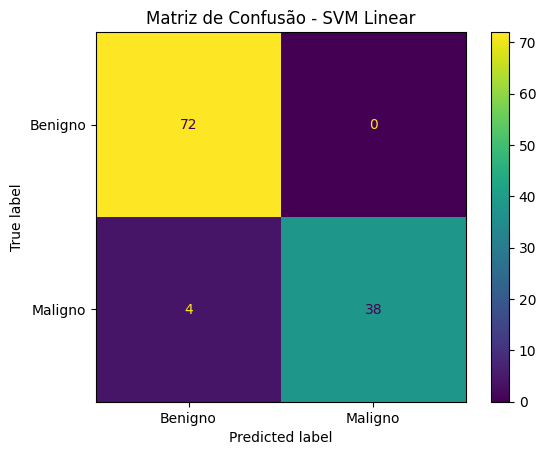

In [120]:
# Calcula a matriz de confusão
matriz_linear = sklearn.metrics.confusion_matrix(
    y_test,
    y_pred_linear
)

# Prepara a visualização da matriz
grafico_linear = sklearn.metrics.ConfusionMatrixDisplay(
    confusion_matrix=matriz_linear,
    display_labels=['Benigno', 'Maligno']
)

# Mostra a matriz
grafico_linear.plot()

plt.title('Matriz de Confusão - SVM Linear')
plt.show()

## Matriz de Confusão do SVM Linear

Também utilizei uma matriz de confusão para visualizar melhor os acertos
e erros realizados pelo modelo.

Com ela consigo observar separadamente os casos benignos e malignos que
foram classificados corretamente e também aqueles que foram confundidos
pelo modelo.

Isso é interessante porque somente a Accuracy não mostra exatamente em
qual classe os erros aconteceram.

In [121]:
# Cria um segundo SVM utilizando o kernel RBF
svm_rbf = sklearn.svm.SVC(
    kernel='rbf',
    C=1,
    gamma='scale'
)

# Treina o modelo
svm_rbf.fit(X_train_scaled, y_train)

# Realiza as previsões
y_pred_rbf = svm_rbf.predict(X_test_scaled)

## SVM com Kernel RBF

Depois do modelo Linear, criei um segundo SVM utilizando o kernel RBF.

O RBF consegue trabalhar com separações mais complexas entre os dados,
não ficando limitado somente a uma divisão linear.

Inicialmente utilizei C igual a 1 e gamma como "scale".

Depois vou testar outros valores desses parâmetros para descobrir quais
funcionam melhor para este conjunto de dados.

In [122]:
# Calcula as métricas do SVM RBF
accuracy_rbf = sklearn.metrics.accuracy_score(
    y_test, y_pred_rbf
)

precision_rbf = sklearn.metrics.precision_score(
    y_test, y_pred_rbf
)

recall_rbf = sklearn.metrics.recall_score(
    y_test, y_pred_rbf
)

f1_rbf = sklearn.metrics.f1_score(
    y_test, y_pred_rbf
)

# Mostra os resultados
print("Accuracy:", accuracy_rbf)
print("Precision:", precision_rbf)
print("Recall:", recall_rbf)
print("F1-score:", f1_rbf)

Accuracy: 0.9736842105263158
Precision: 1.0
Recall: 0.9285714285714286
F1-score: 0.9629629629629629


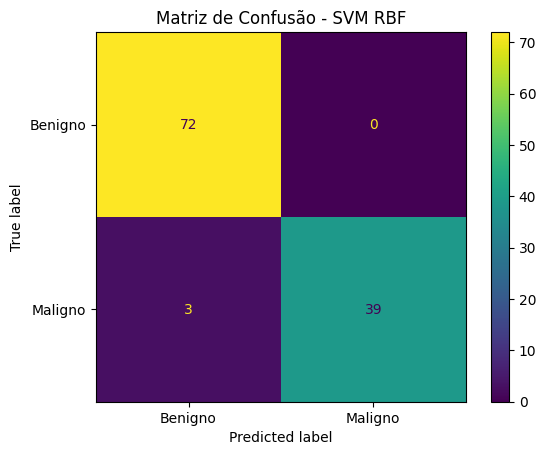

In [123]:
# Cria a matriz de confusão do RBF
matriz_rbf = sklearn.metrics.confusion_matrix(
    y_test,
    y_pred_rbf
)

# Prepara a visualização
grafico_rbf = sklearn.metrics.ConfusionMatrixDisplay(
    confusion_matrix=matriz_rbf,
    display_labels=['Benigno', 'Maligno']
)

# Mostra a matriz
grafico_rbf.plot()

plt.title('Matriz de Confusão - SVM RBF')
plt.show()

## Avaliação do SVM RBF

Assim como no modelo Linear, avaliei o SVM RBF utilizando Accuracy,
Precision, Recall e F1-score.

Também criei uma matriz de confusão para conseguir visualizar os acertos
e erros do modelo.

Com esses resultados já é possível fazer uma primeira comparação entre
o comportamento do kernel Linear e do kernel RBF.

In [124]:
# Valores de C que serão testados
parametros_linear = {
    'C': [0.01, 0.1, 1, 10, 100]
}

# Cria o GridSearch para procurar o melhor valor
grid_linear = sklearn.model_selection.GridSearchCV(
    sklearn.svm.SVC(kernel='linear'),
    parametros_linear,
    cv=5,
    scoring='accuracy'
)

# Realiza os testes utilizando os dados de treinamento
grid_linear.fit(X_train_scaled, y_train)

# Mostra o melhor resultado encontrado
print("Melhor valor de C:", grid_linear.best_params_)
print("Melhor resultado:", grid_linear.best_score_)

Melhor valor de C: {'C': 0.01}
Melhor resultado: 0.9692307692307693


## Ajuste do SVM Linear

Depois do primeiro treinamento, procurei melhorar o modelo testando
diferentes valores para o parâmetro C.

Para isso utilizei o GridSearchCV. Ele testa automaticamente os valores
que informei e utiliza validação cruzada para comparar os resultados.

Neste caso foram testados os valores 0.01, 0.1, 1, 10 e 100.

Dessa forma, não preciso escolher o valor de C apenas por tentativa.
O próprio processo de validação ajuda a encontrar o valor que apresentou
o melhor resultado nos dados de treinamento.

In [125]:
# Valores de C e gamma que serão testados
parametros_rbf = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 0.001, 0.01, 0.1, 1]
}

# Cria o GridSearch para o SVM RBF
grid_rbf = sklearn.model_selection.GridSearchCV(
    sklearn.svm.SVC(kernel='rbf'),
    parametros_rbf,
    cv=5,
    scoring='accuracy'
)

# Testa as diferentes combinações
grid_rbf.fit(X_train_scaled, y_train)

# Mostra os melhores parâmetros encontrados
print("Melhores parâmetros:", grid_rbf.best_params_)
print("Melhor resultado:", grid_rbf.best_score_)

Melhores parâmetros: {'C': 1, 'gamma': 'scale'}
Melhor resultado: 0.9758241758241759


## Ajuste do SVM RBF

No modelo RBF realizei um teste um pouco maior.

Além do parâmetro C, também testei diferentes valores de gamma.

De forma simples, C está relacionado com o quanto o modelo penaliza
erros durante o treinamento. Já gamma influencia o alcance que cada
exemplo possui na construção da separação realizada pelo RBF.

Utilizei novamente o GridSearchCV para testar diferentes combinações
e encontrar os valores que apresentaram melhor resultado durante a
validação cruzada.

In [126]:
# Pega o melhor modelo Linear encontrado
melhor_linear = grid_linear.best_estimator_

# Pega o melhor modelo RBF encontrado
melhor_rbf = grid_rbf.best_estimator_

# Realiza as previsões no conjunto de teste
y_pred_melhor_linear = melhor_linear.predict(X_test_scaled)
y_pred_melhor_rbf = melhor_rbf.predict(X_test_scaled)

## Teste dos modelos ajustados

Depois de encontrar os melhores parâmetros, utilizei os modelos escolhidos
pelo GridSearchCV para fazer novas previsões.

É importante destacar que o ajuste foi realizado utilizando os dados de
treinamento. Somente depois disso utilizei o conjunto de teste para
avaliar o resultado final.

In [127]:
# Cria uma tabela para comparar os quatro modelos
resultados = pd.DataFrame({
    'Modelo': [
        'SVM Linear',
        'SVM RBF',
        'SVM Linear Ajustado',
        'SVM RBF Ajustado'
    ],

    'Accuracy': [
        sklearn.metrics.accuracy_score(y_test, y_pred_linear),
        sklearn.metrics.accuracy_score(y_test, y_pred_rbf),
        sklearn.metrics.accuracy_score(y_test, y_pred_melhor_linear),
        sklearn.metrics.accuracy_score(y_test, y_pred_melhor_rbf)
    ],

    'Precision': [
        sklearn.metrics.precision_score(y_test, y_pred_linear),
        sklearn.metrics.precision_score(y_test, y_pred_rbf),
        sklearn.metrics.precision_score(y_test, y_pred_melhor_linear),
        sklearn.metrics.precision_score(y_test, y_pred_melhor_rbf)
    ],

    'Recall': [
        sklearn.metrics.recall_score(y_test, y_pred_linear),
        sklearn.metrics.recall_score(y_test, y_pred_rbf),
        sklearn.metrics.recall_score(y_test, y_pred_melhor_linear),
        sklearn.metrics.recall_score(y_test, y_pred_melhor_rbf)
    ],

    'F1-score': [
        sklearn.metrics.f1_score(y_test, y_pred_linear),
        sklearn.metrics.f1_score(y_test, y_pred_rbf),
        sklearn.metrics.f1_score(y_test, y_pred_melhor_linear),
        sklearn.metrics.f1_score(y_test, y_pred_melhor_rbf)
    ]
})

# Mostra os resultados com 4 casas decimais
resultados.round(4)

,Modelo,Accuracy,Precision,Recall,F1-score
0,SVM Linear,0.9649,1.0,0.9048,0.9500
1,SVM RBF,0.9737,1.0,0.9286,0.9630
2,SVM Linear Ajustado,0.9561,1.0,0.8810,0.9367
3,SVM RBF Ajustado,0.9737,1.0,0.9286,0.9630


## Comparação dos resultados

Para facilitar a comparação, reuni os resultados dos modelos em uma
única tabela.

Comparei tanto os modelos iniciais quanto os modelos depois do ajuste
dos parâmetros.

Utilizei Accuracy, Precision, Recall e F1-score porque olhar apenas uma
métrica poderia não mostrar completamente o comportamento dos modelos.

A tabela facilita bastante a visualização das diferenças entre o kernel
Linear e o RBF e também permite observar se o ajuste dos parâmetros
melhorou os resultados.

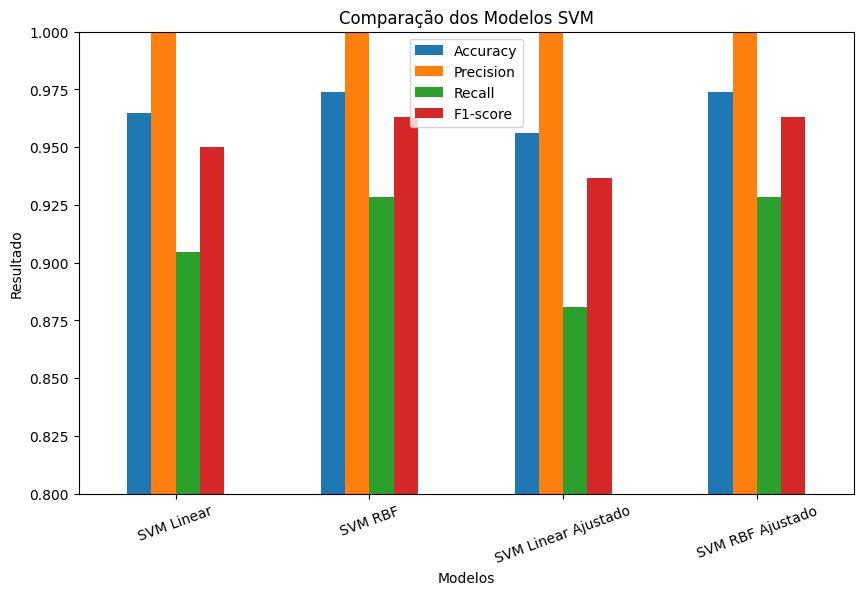

In [128]:
# Coloca o nome dos modelos como índice
grafico_resultados = resultados.set_index('Modelo')

# Cria o gráfico comparando as métricas
grafico_resultados.plot(
    kind='bar',
    figsize=(10, 6)
)

# Configurações do gráfico
plt.title('Comparação dos Modelos SVM')
plt.xlabel('Modelos')
plt.ylabel('Resultado')

# Define a escala do gráfico
plt.ylim(0.8, 1.0)

# Ajusta os nomes
plt.xticks(rotation=20)

# Mostra o gráfico
plt.show()

## Comparação visual

Além da tabela, criei um gráfico para visualizar melhor os resultados.

Cada modelo pode ser comparado utilizando as quatro métricas escolhidas.

Essa visualização torna mais fácil perceber as diferenças entre os
modelos antes e depois do ajuste dos hiperparâmetros.

In [129]:
# Mostra os melhores parâmetros encontrados para cada kernel
print("Melhor configuração do Linear:")
print(grid_linear.best_params_)

print()

print("Melhor configuração do RBF:")
print(grid_rbf.best_params_)

Melhor configuração do Linear:
{'C': 0.01}

Melhor configuração do RBF:
{'C': 1, 'gamma': 'scale'}


In [130]:
# Procura qual linha possui o maior F1-score
indice_melhor = resultados['F1-score'].idxmax()

# Mostra o resultado
print(resultados.loc[indice_melhor])

Modelo        SVM RBF
Accuracy     0.973684
Precision         1.0
Recall       0.928571
F1-score     0.962963
Name: 1, dtype: object


# Conclusão

Nesta atividade utilizei o algoritmo Support Vector Machine (SVM) para
classificar tumores como benignos ou malignos utilizando o dataset
Breast Cancer Wisconsin.

Primeiro procurei conhecer melhor os dados e identificar informações que
não seriam necessárias para o treinamento. Depois realizei a limpeza,
transformei o diagnóstico em valores numéricos e separei as características
da variável que deveria ser prevista.

Também realizei a padronização utilizando o StandardScaler. Essa etapa
foi importante porque as características possuem escalas diferentes e
isso poderia influenciar o funcionamento do SVM.

Após o pré-processamento, separei os dados em treinamento e teste e criei
dois modelos SVM, um utilizando o kernel Linear e outro utilizando o
kernel RBF.

Depois utilizei o GridSearchCV para testar diferentes valores de C e
gamma e encontrar configurações melhores para os modelos.

Para avaliar os resultados, utilizei Accuracy, Precision, Recall,
F1-score e matriz de confusão. Dessa forma, consegui analisar não apenas
a quantidade geral de acertos, mas também como os modelos se comportaram
na identificação dos tumores benignos e malignos.

Comparando os resultados obtidos, foi possível observar as diferenças
entre os kernels e também verificar o efeito do ajuste dos
hiperparâmetros.

Com essa atividade consegui entender melhor na prática como funciona o
processo de preparação dos dados, treinamento, ajuste e avaliação de um
modelo SVM para um problema de classificação binária.